In [88]:
import pandas as pd 
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [89]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

cuda
NVIDIA GeForce RTX 5060 Laptop GPU


In [90]:
train_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.5, 0.5, 0.5],
        [0.5, 0.5, 0.5]
    )
])

In [91]:
train_set = datasets.CIFAR10(
    root = "./data", 
    train = True,
    download = True,
    transform = train_transform 
)

100%|██████████| 170M/170M [17:18<00:00, 164kB/s]  


In [92]:
train_loader = DataLoader(
    train_set, 
    batch_size = 128,
    shuffle = True 
)

In [93]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Conv2d(256, 1, kernel_size=4, stride=1, padding=0),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.model(x)
        return x 

In [94]:
discriminator = Discriminator().to(device)
discriminator 

Discriminator(
  (model): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Conv2d(256, 1, kernel_size=(4, 4), stride=(1, 1))
    (9): Sigmoid()
  )
)

In [95]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(100, 256, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(256),
            nn.ReLU(0.2),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(0.2),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(0.2),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(0.2),
            nn.Conv2d(32, 3, kernel_size=3, stride=1, padding=1),

            nn.Tanh()

        )

    def forward(self, x):
        x = self.model(x)
        return x 

In [96]:
generator = Generator().to(device)
generator

Generator(
  (model): Sequential(
    (0): ConvTranspose2d(100, 256, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (10): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): Tanh()
  )
)

In [97]:
criterion = nn.BCELoss()
optimizer_Dis = torch.optim.Adam(
    discriminator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

optimizer_Gen = torch.optim.Adam(
    generator.parameters(),
    lr=0.0002,
    betas=(0.5, 0.999)
)

In [98]:
from torchvision.utils import save_image
import os

os.makedirs("generated_images_DCGAN", exist_ok=True)

In [99]:
epochs = 150

generator.train()
discriminator.train()

for epoch in range(epochs):

    for real_images, _ in train_loader:

        batch_size = real_images.size(0)

        real_images = real_images.to(device)

        # -----------------------------
        # Train Discriminator
        # -----------------------------

        optimizer_Dis.zero_grad()

        # Real images
        real_labels = torch.ones(batch_size, 1, 1, 1).to(device)

        output_real = discriminator(real_images)

        loss_real = criterion(output_real, real_labels)

        # Fake images
        noise = torch.randn(batch_size, 100, 1, 1).to(device)

        fake_images = generator(noise)

        fake_labels = torch.zeros(batch_size, 1, 1, 1).to(device)

        output_fake = discriminator(fake_images.detach())

        loss_fake = criterion(output_fake, fake_labels)

        # Total discriminator loss
        loss_Dis = loss_real + loss_fake

        loss_Dis.backward()

        optimizer_Dis.step()

        # -----------------------------
        # Train Generator
        # -----------------------------

        optimizer_Gen.zero_grad()

        noise = torch.randn(batch_size, 100, 1, 1).to(device)

        fake_images = generator(noise)

        output = discriminator(fake_images)

        # Generator wants discriminator to predict REAL
        loss_Gen = criterion(output, real_labels)

        loss_Gen.backward()

        optimizer_Gen.step()

    print(f"Epoch [{epoch+1}/{epochs}]  Dis_Loss: {loss_Dis.item():.4f} Gen_Loss: {loss_Gen.item():.4f}")


    if (epoch + 1) % 5 == 0:

        generator.eval()

        with torch.no_grad():

            noise = torch.randn(16, 100, 1, 1).to(device)

            fake_images = generator(noise)

            save_image(
                fake_images,
                f"generated_images_DCGAN/epoch_{epoch+1}.png",
                nrow=4,
                normalize=True
            )

        generator.train()

Epoch [1/150]  Dis_Loss: 0.7321 Gen_Loss: 3.0757
Epoch [2/150]  Dis_Loss: 0.5672 Gen_Loss: 2.4041
Epoch [3/150]  Dis_Loss: 0.4725 Gen_Loss: 3.1729
Epoch [4/150]  Dis_Loss: 0.7411 Gen_Loss: 2.9595
Epoch [5/150]  Dis_Loss: 0.8833 Gen_Loss: 2.8718
Epoch [6/150]  Dis_Loss: 0.8211 Gen_Loss: 1.5453
Epoch [7/150]  Dis_Loss: 1.0207 Gen_Loss: 1.5102
Epoch [8/150]  Dis_Loss: 0.9319 Gen_Loss: 1.3704
Epoch [9/150]  Dis_Loss: 0.9346 Gen_Loss: 1.7366
Epoch [10/150]  Dis_Loss: 0.8702 Gen_Loss: 1.9035
Epoch [11/150]  Dis_Loss: 1.0040 Gen_Loss: 0.9697
Epoch [12/150]  Dis_Loss: 0.8889 Gen_Loss: 1.3664
Epoch [13/150]  Dis_Loss: 1.0982 Gen_Loss: 0.7202
Epoch [14/150]  Dis_Loss: 1.0297 Gen_Loss: 1.7094
Epoch [15/150]  Dis_Loss: 0.9303 Gen_Loss: 1.4659
Epoch [16/150]  Dis_Loss: 0.9547 Gen_Loss: 1.6096
Epoch [17/150]  Dis_Loss: 0.8983 Gen_Loss: 0.8498
Epoch [18/150]  Dis_Loss: 0.8708 Gen_Loss: 2.2068
Epoch [19/150]  Dis_Loss: 1.0712 Gen_Loss: 1.1973
Epoch [20/150]  Dis_Loss: 0.8954 Gen_Loss: 1.4990
Epoch [21

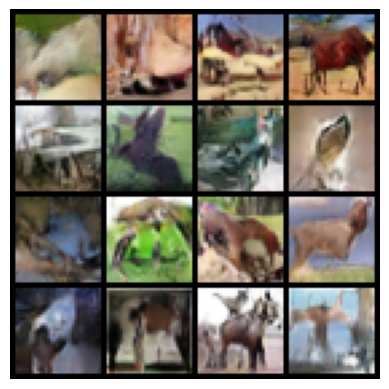

In [100]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("generated_images_DCGAN/epoch_150.png")

plt.imshow(img)
plt.axis("off")
plt.show()

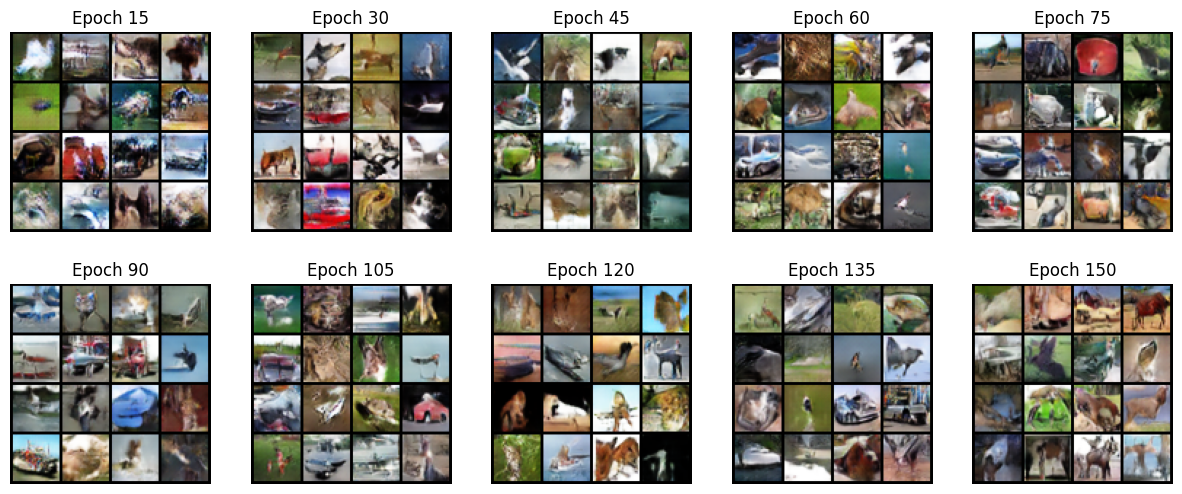

In [101]:
from PIL import Image
import matplotlib.pyplot as plt

epochs = [15,30,45,60,75,90,105,120,135,150]

fig, axes = plt.subplots(2,5, figsize=(15,6))

for ax, ep in zip(axes.flatten(), epochs):
    img = Image.open(f"generated_images_DCGAN/epoch_{ep}.png")
    ax.imshow(img)
    ax.set_title(f"Epoch {ep}")
    ax.axis("off")

plt.show()